## We developed an AI model for student replacement prediction using deep learning and regression algorithms. We will aim high R2 value. This AI model can also be found in the Streamlit application HuggingFace.¶

<img src='https://student-cms.prd.timeshighereducation.com/sites/default/files/styles/default/public/istock-483479827.jpg?itok=lNJYPIwF'>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/suhanigupta04/student-placement-prediction-dataset/student_placement_synthetic.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/kaggle/input/datasets/suhanigupta04/student-placement-prediction-dataset/student_placement_synthetic.csv')
df.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42


## EDA (Exploratory Data Analysis)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   branch                     100000 non-null  object 
 1   college_tier               100000 non-null  object 
 2   cgpa                       100000 non-null  float64
 3   backlogs                   100000 non-null  int64  
 4   coding_skills              100000 non-null  float64
 5   dsa_score                  100000 non-null  float64
 6   aptitude_score             100000 non-null  float64
 7   communication_skills       100000 non-null  float64
 8   ml_knowledge               100000 non-null  float64
 9   system_design              100000 non-null  float64
 10  internships                100000 non-null  int64  
 11  projects_count             100000 non-null  int64  
 12  certifications             100000 non-null  int64  
 13  hackathons                 100

In [5]:
df.isnull().sum()

branch                           0
college_tier                     0
cgpa                             0
backlogs                         0
coding_skills                    0
dsa_score                        0
aptitude_score                   0
communication_skills             0
ml_knowledge                     0
system_design                    0
internships                      0
projects_count                   0
certifications                   0
hackathons                       0
open_source_contributions        0
extracurriculars                 0
placement_status                 0
salary_package_lpa           31525
dtype: int64

<Axes: ylabel='count'>

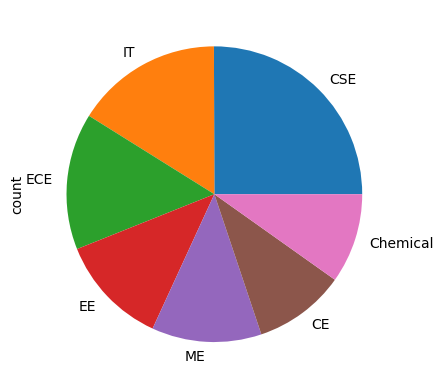

In [6]:
df["branch"].value_counts().plot.pie()

<Axes: ylabel='count'>

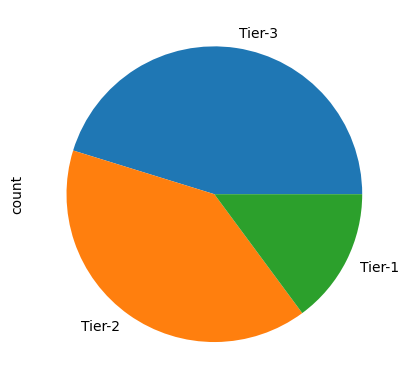

In [7]:
df["college_tier"].value_counts().plot.pie()

<Axes: xlabel='salary_package_lpa', ylabel='Density'>

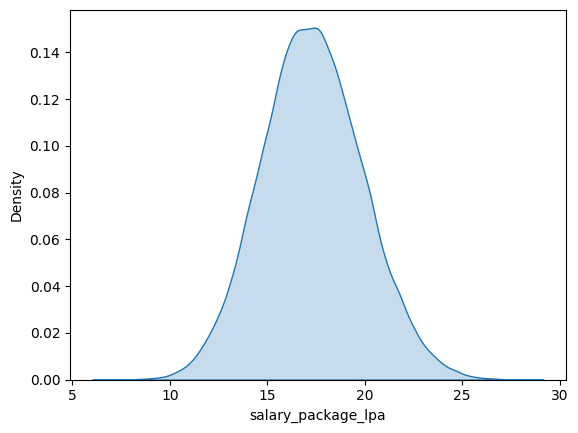

In [8]:
sns.kdeplot(x=df['salary_package_lpa'], fill=True)

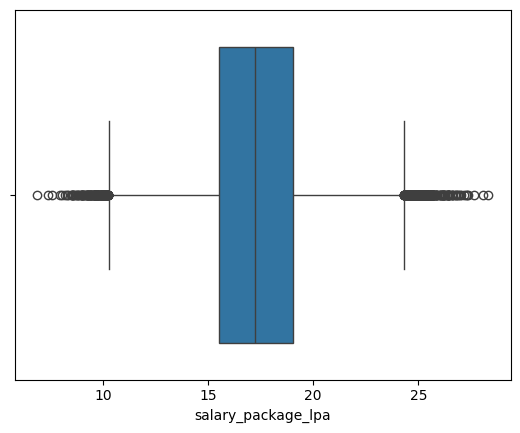

In [9]:
sns.boxplot(x=df['salary_package_lpa']);

<Axes: >

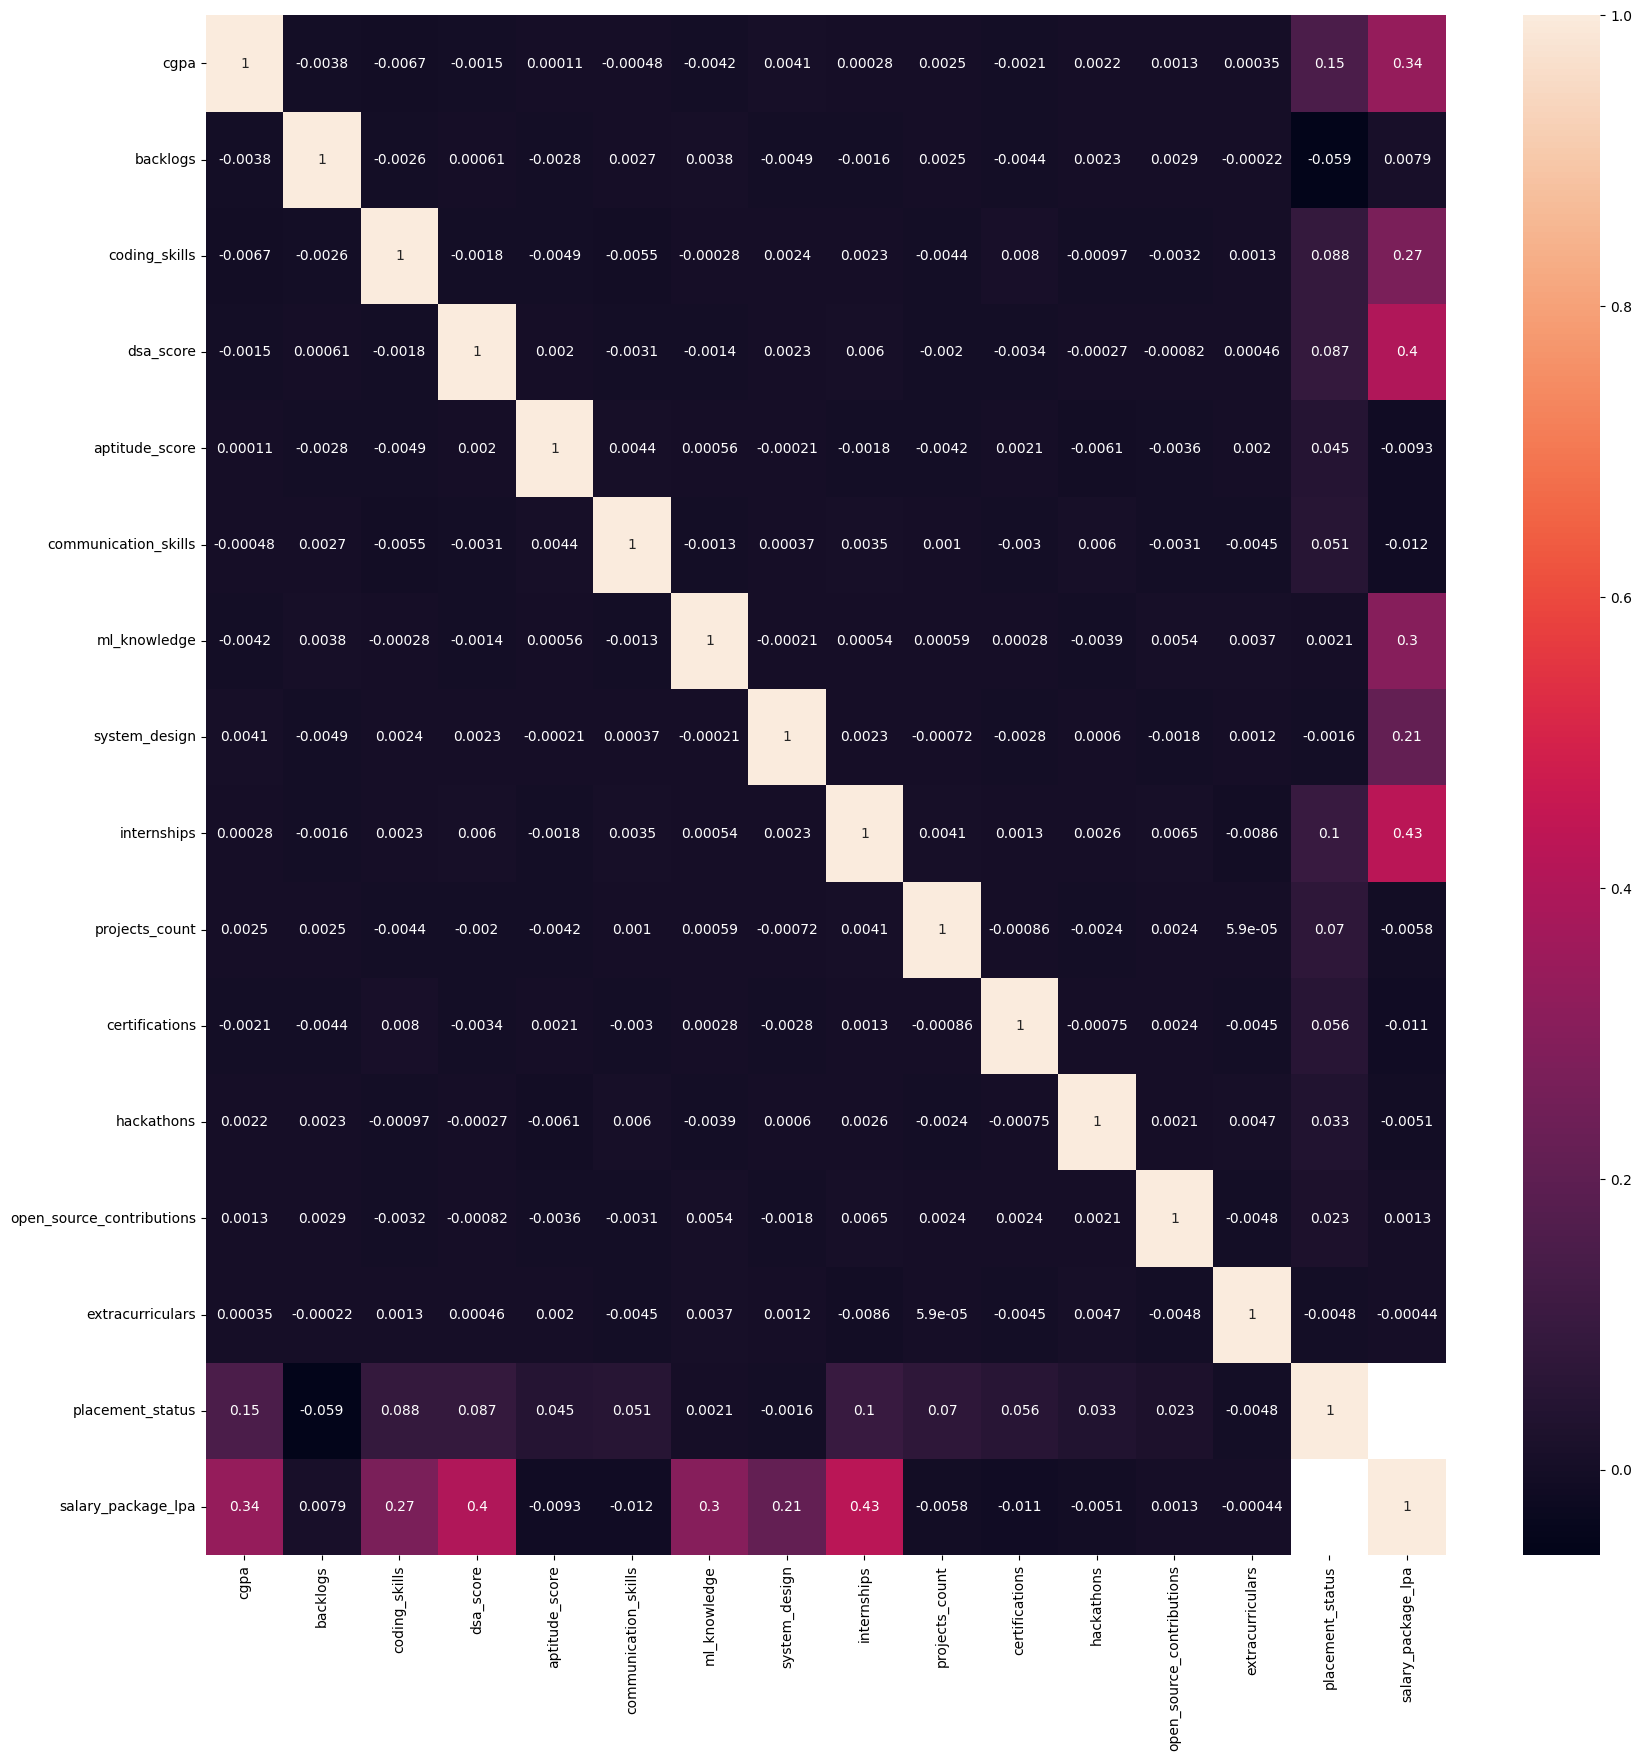

In [10]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [11]:
df['salary_package_lpa'] = df['salary_package_lpa'].fillna(df['salary_package_lpa'].mean())

In [12]:
df.isnull().sum()

branch                       0
college_tier                 0
cgpa                         0
backlogs                     0
coding_skills                0
dsa_score                    0
aptitude_score               0
communication_skills         0
ml_knowledge                 0
system_design                0
internships                  0
projects_count               0
certifications               0
hackathons                   0
open_source_contributions    0
extracurriculars             0
placement_status             0
salary_package_lpa           0
dtype: int64

# Train AI with Deep Learning Algorithm

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler

2026-03-28 13:32:21.952338: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774704742.199713      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774704742.267626      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774704742.845093      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774704742.845163      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774704742.845166      17 computation_placer.cc:177] computation placer alr

In [14]:
scaler=StandardScaler()

In [15]:
model=Sequential()
model.add(Dense(80,activation='relu')) # hayal urunu
model.add(Dense(120,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(1)) # sigmoid yok regression olduğu için


model.compile(loss='mean_squared_error', optimizer='adam')

2026-03-28 13:32:45.916626: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [16]:
from sklearn.model_selection import train_test_split

In [17]:
x=df.drop('placement_status', axis=1)
y=df[['placement_status']]

In [18]:
x=pd.get_dummies(x, drop_first=True)

In [19]:
x

,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,...,extracurriculars,salary_package_lpa,branch_CSE,branch_Chemical,branch_ECE,branch_EE,branch_IT,branch_ME,college_tier_Tier-2,college_tier_Tier-3
0,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,...,1,14.750000,False,False,True,False,False,False,False,True
1,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,...,0,17.308014,False,True,False,False,False,False,True,False
2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,...,0,19.060000,False,False,False,True,False,False,True,False
3,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,...,0,17.308014,False,False,False,False,False,False,True,False
4,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,...,1,13.420000,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,6.08,0,3.1,5.4,67.4,4.3,9.1,3.8,2,3,...,3,17.308014,False,False,False,False,True,False,False,True
99996,7.46,0,4.8,6.8,59.5,7.6,5.6,2.4,1,2,...,0,16.580000,False,False,False,False,True,False,False,True
99997,7.94,0,4.9,9.1,55.1,6.1,3.5,5.2,0,2,...,2,17.240000,False,False,False,True,False,False,True,False
99998,6.63,0,5.0,8.0,65.0,5.7,6.2,0.2,1,4,...,1,17.010000,False,False,False,False,False,True,False,True


In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=.20,random_state=42)

In [21]:
history=model.fit(x_train,y_train, epochs=50,batch_size=64, validation_data=(x_test,y_test),verbose=1)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2224 - val_loss: 0.1605
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1578 - val_loss: 0.1377
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1428 - val_loss: 0.1301
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1328 - val_loss: 0.1220
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1235 - val_loss: 0.1051
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1048 - val_loss: 0.0823
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0877 - val_loss: 0.0857
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0840 - val_loss: 0.0866
Epoch 9/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0757 - val_loss: 0.0607
Epoch 10/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0752 - val_loss: 0.1119
Epoch 11/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0813 - val_loss: 0.0498
Epoch 12/50
1250/1250 ━━━━━━━━

In [22]:
prediction=model.predict(x_test)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [23]:
from sklearn.metrics import r2_score, mean_squared_error

In [24]:
r2_score(y_test,prediction)

0.7518353462219238

In [25]:
model.save('Student_Placement Prediction.h5')

In [26]:
model.save('Student_Placement Prediction.keras')

## We developed an AI model for salary prediction using deep learning and regression algorithms. We achieved an R2 value of 0.7998. This AI model can also be found in the Streamlit application HuggingFace.¶